In [1]:
import gc
gc.collect()

89

In [22]:
import sys

import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.signal import butter, lfilter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# EEGNet-specific imports
from EEGModels import EEGNet
from tensorflow.keras import utils as np_utils
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import backend as K

import tensorflow.keras as keras
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import backend as K
import tensorflow.keras.models as models
import tensorflow.compat.v1 as tf
import numpy as np
from tslearn.metrics import soft_dtw
import os
import mne
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Permute, Dropout, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import SeparableConv2D, DepthwiseConv2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import SpatialDropout2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.layers import Input, Flatten
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import backend as K
from scipy.signal import butter, filtfilt
from sklearn.model_selection import KFold
from scipy import io, signal
import math

import json

def extract_accuracies_from_file(file_path):
    # Open and load the JSON file
    with open(file_path, 'r') as file:
        json_data = json.load(file)
    
    # Extract the accuracies into a list
    accuracies = [data[0].get("accuracy", None) for data in json_data.values()]
    return accuracies
    
def calculate_itr(classification_acc, num_targets, target_selection_time_seconds):          
    p = classification_acc
    logp = np.log2(p)
    ip = 1.0 - p

    a = np.log2(num_targets)
    b = p * logp
    c = ip * np.log2( ip/(num_targets-1) )
    result = a + b + c
    return result * (60 / target_selection_time_seconds)


In [7]:
# type_lowcut_segments

cca_8_100 = np.array(extract_accuracies_from_file("results/cca_results_9chan_8_90_0.4s.json")) / 100
cca_8_150 = np.array(extract_accuracies_from_file("results/cca_results_9chan_8_90_0.6s.json")) / 100
cca_8_200 = np.array(extract_accuracies_from_file("results/cca_results_9chan_8_90_0.8s.json")) / 100
cca_8_250 = np.array(extract_accuracies_from_file("results/cca_results_9chan_8_90_1.0s.json")) / 100

cca_16_100 = np.array(extract_accuracies_from_file("results/cca_results_9chan_16_90_0.4s.json")) / 100
cca_16_150 = np.array(extract_accuracies_from_file("results/cca_results_9chan_16_90_0.6s.json")) / 100
cca_16_200 = np.array(extract_accuracies_from_file("results/cca_results_9chan_16_90_0.8s.json")) / 100
cca_16_250 = np.array(extract_accuracies_from_file("results/cca_results_9chan_16_90_1.0s.json")) / 100

cca_24_100 = np.array(extract_accuracies_from_file("results/cca_results_9chan_24_90_0.4s.json")) / 100
cca_24_150 = np.array(extract_accuracies_from_file("results/cca_results_9chan_24_90_0.6s.json")) / 100
cca_24_200 = np.array(extract_accuracies_from_file("results/cca_results_9chan_24_90_0.8s.json")) / 100
cca_24_250 = np.array(extract_accuracies_from_file("results/cca_results_9chan_24_90_1.0s.json")) / 100

eeg_8_100 = extract_accuracies_from_file("results/eeg_results2_9chans_8_90_100.json")
eeg_8_150 = extract_accuracies_from_file("results/eeg_results2_9chans_8_90_150.json")
eeg_8_200 = extract_accuracies_from_file("results/eeg_results2_9chans_8_90_200.json")
eeg_8_250 = extract_accuracies_from_file("results/eeg_results2_9chans_8_90_250.json")

eeg_16_100 = extract_accuracies_from_file("results/eeg_results2_9chans_16_90_100.json")
eeg_16_150 = extract_accuracies_from_file("results/eeg_results2_9chans_16_90_150.json")
eeg_16_200 = extract_accuracies_from_file("results/eeg_results2_9chans_16_90_200.json")
eeg_16_250 = extract_accuracies_from_file("results/eeg_results2_9chans_16_90_250.json")

eeg_24_100 = extract_accuracies_from_file("results/eeg_results2_9chans_24_90_100.json")
eeg_24_150 = extract_accuracies_from_file("results/eeg_results2_9chans_24_90_150.json")
eeg_24_200 = extract_accuracies_from_file("results/eeg_results2_9chans_24_90_200.json")
eeg_24_250 = extract_accuracies_from_file("results/eeg_results2_9chans_24_90_250.json")

eeg_fusion3_100 = extract_accuracies_from_file("results/eeg_fusion3_results_9chans_90_100.json")
eeg_fusion3_150 = extract_accuracies_from_file("results/eeg_fusion3_results_9chans_90_150.json")
eeg_fusion3_200 = extract_accuracies_from_file("results/eeg_fusion3_results_9chans_90_200.json")
eeg_fusion3_250 = extract_accuracies_from_file("results/eeg_fusion3_results_9chans_90_250.json")

accuracies1 = [
    cca_8_100, cca_8_150, cca_8_200, cca_8_250,  # CCA model
    eeg_8_100, eeg_8_150, eeg_8_200, eeg_8_250,  # EEG model
    eeg_fusion3_100, eeg_fusion3_150, eeg_fusion3_200, eeg_fusion3_250  # EEG FUSION model
]

#print(calculate_itr(np.mean(eeg_8_100), 10, 0.4))
#print(calculate_itr(np.mean(eeg_8_150), 10, 0.6))
#print(calculate_itr(np.mean(eeg_8_200), 10, 0.8))
#print(calculate_itr(np.mean(eeg_8_250), 10, 1.0))

itr_time = [0.4,0.6,0.8,1.0] * 3
itr_time2 = [0.4, 0.6, 0.8, 1.0]

mean_accuracies1 = [np.mean(acc) for acc in accuracies1]
std_devs1 = [np.std(acc) for acc in accuracies1]

accuracies2 = [
    cca_16_100, cca_16_150, cca_16_200, cca_16_250,  # CCA model
    eeg_16_100, eeg_16_150, eeg_16_200, eeg_16_250,  # EEG model
    eeg_fusion3_100, eeg_fusion3_150, eeg_fusion3_200, eeg_fusion3_250  # EEG FUSION model
]

mean_accuracies2 = [np.mean(acc) for acc in accuracies2]
std_devs2 = [np.std(acc) for acc in accuracies2]

accuracies3 = [
    cca_24_100, cca_24_150, cca_24_200, cca_24_250,  # CCA model
    eeg_24_100, eeg_24_150, eeg_24_200, eeg_24_250,  # EEG model
    eeg_fusion3_100, eeg_fusion3_150, eeg_fusion3_200, eeg_fusion3_250  # EEG FUSION model
]

mean_accuracies3 = [np.mean(acc) for acc in accuracies3]
std_devs3 = [np.std(acc) for acc in accuracies3]

itr1 = [calculate_itr(mean_accuracies1[i], 10, itr_time[i]) for i in range(len(mean_accuracies1))]
itr1_std = []
for i in range(len(accuracies1)):
    itrs = []
    for acc in accuracies1[i]:
        itrs.append(calculate_itr(acc, 10, itr_time[i]))
    itr1_std.append(np.std(itrs))

itr2 = [calculate_itr(mean_accuracies2[i], 10, itr_time[i]) for i in range(len(mean_accuracies2))]
itr2_std = []
for i in range(len(accuracies2)):
    itrs = []
    for acc in accuracies1[2]:
        itrs.append(calculate_itr(acc, 10, itr_time[i]))
    itr2_std.append(np.std(itrs))

itr3 = [calculate_itr(mean_accuracies3[i], 10, itr_time[i]) for i in range(len(mean_accuracies3))]
itr3_std = []
for i in range(len(accuracies1)):
    itrs = []
    for acc in accuracies1[i]:
        itrs.append(calculate_itr(acc, 10, itr_time[i]))
    itr1_std.append(np.std(itrs))


C:\Users\qianqian\AppData\Local\Temp\ipykernel_17952\4275466635.py:62: RuntimeWarning: divide by zero encountered in log2
  c = ip * np.log2( ip/(num_targets-1) )
C:\Users\qianqian\AppData\Local\Temp\ipykernel_17952\4275466635.py:62: RuntimeWarning: invalid value encountered in scalar multiply
  c = ip * np.log2( ip/(num_targets-1) )


# Segment length vs accuracy

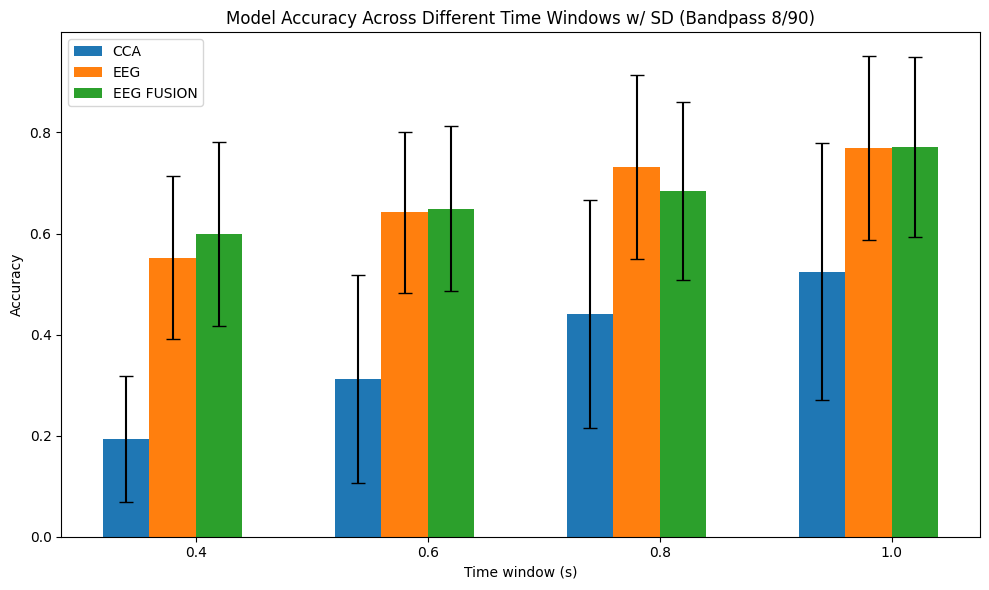

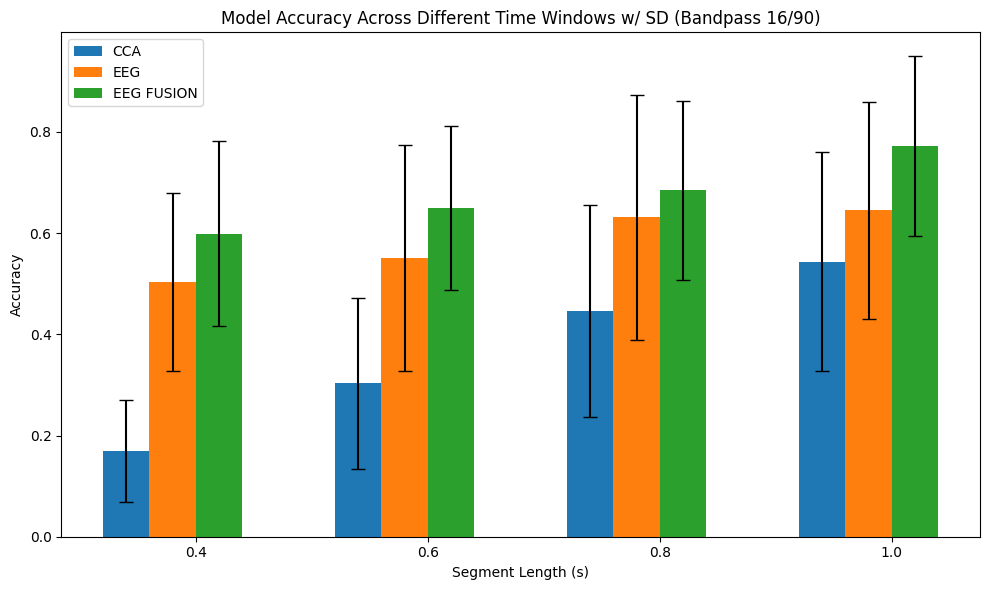

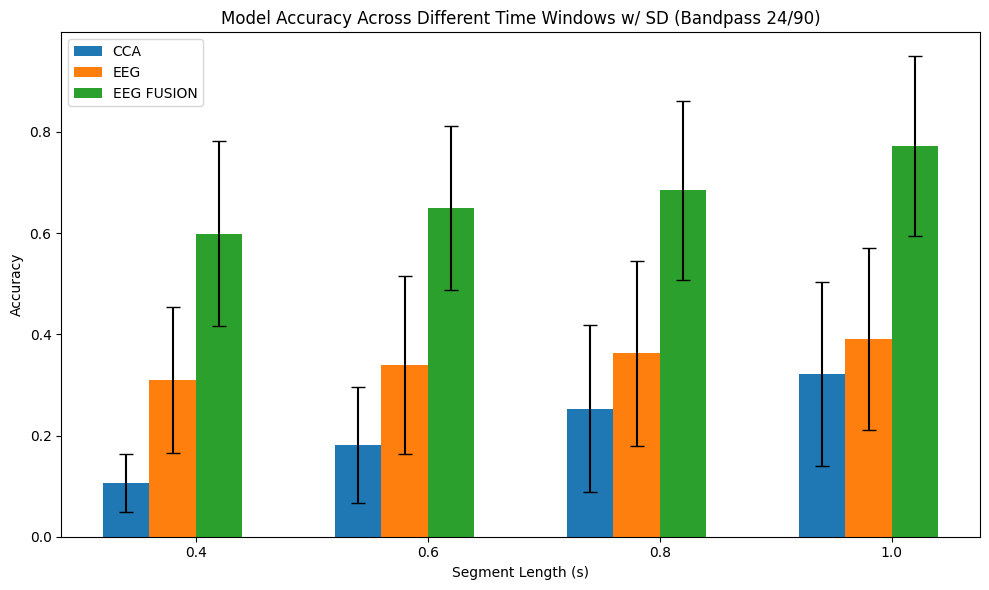

In [8]:
models = ['CCA', 'EEG', 'EEG FUSION']
segment_lengths = [0.4, 0.6,0.8, 1.0]

#Filter band 1 (8,90)
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
index = np.arange(len(segment_lengths))

for i, model_name in enumerate(models):
    model_accuracies = mean_accuracies1[i*4:(i+1)*4]
    model_std_devs = std_devs1[i*4:(i+1)*4]
    
    ax.bar(index + i * bar_width, model_accuracies, bar_width, label=model_name,
           yerr=model_std_devs, capsize=5, color='C'+str(i))

ax.set_xlabel('Time window (s)')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Across Different Time Windows w/ SD (Bandpass 8/90)')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(segment_lengths)
ax.legend()

plt.tight_layout()
plt.show()

#Filter band 2 (16,90) 
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
index = np.arange(len(segment_lengths))

for i, model_name in enumerate(models):
    model_accuracies = mean_accuracies2[i*4:(i+1)*4]
    model_std_devs = std_devs2[i*4:(i+1)*4]
    
    ax.bar(index + i * bar_width, model_accuracies, bar_width, label=model_name,
           yerr=model_std_devs, capsize=5, color='C'+str(i))

ax.set_xlabel('Segment Length (s)')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Across Different Time Windows w/ SD (Bandpass 16/90)')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(segment_lengths)
ax.legend()

plt.tight_layout()
plt.show()


#Filter band 3 (24,90)
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
index = np.arange(len(segment_lengths))

for i, model_name in enumerate(models):
    model_accuracies = mean_accuracies3[i*4:(i+1)*4]
    model_std_devs = std_devs3[i*4:(i+1)*4]
    
    ax.bar(index + i * bar_width, model_accuracies, bar_width, label=model_name,
           yerr=model_std_devs, capsize=5, color='C'+str(i))

ax.set_xlabel('Segment Length (s)')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Across Different Time Windows w/ SD (Bandpass 24/90)')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(segment_lengths)
ax.legend()

plt.tight_layout()
plt.show()

# Segment length vs ITR

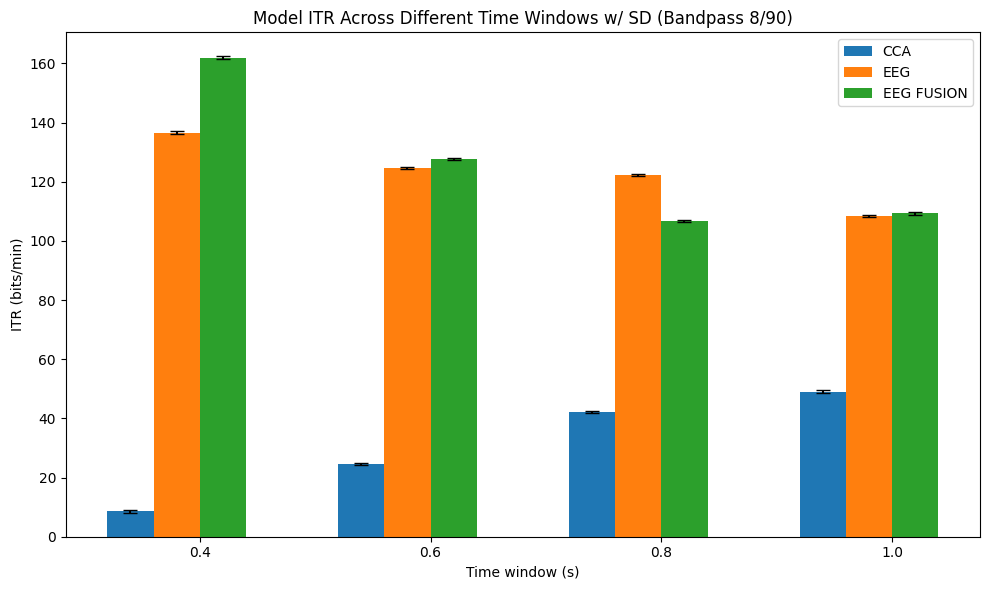

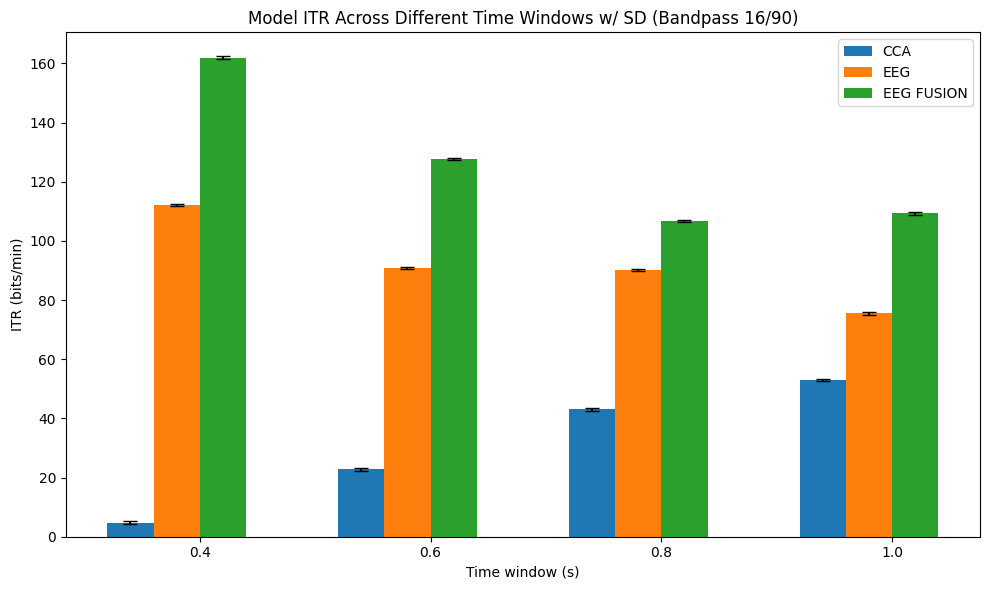

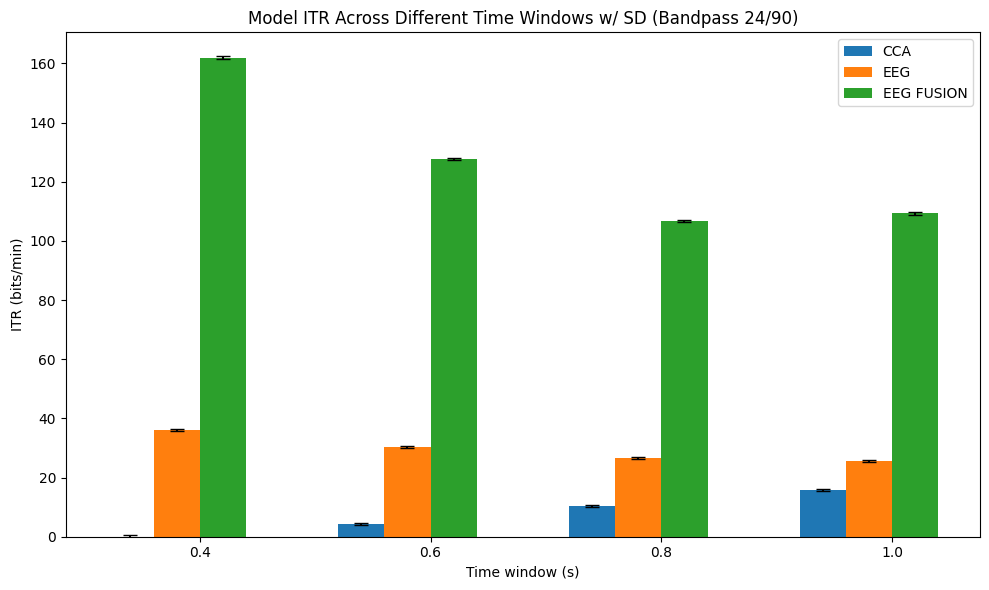

In [9]:


#Filter band 1 (8,90)
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
index = np.arange(len(segment_lengths))

for i, model_name in enumerate(models):
    model_accuracies = mean_accuracies1[i*4:(i+1)*4]
    model_std_devs = std_devs1[i*4:(i+1)*4]
    
    ax.bar(index + i * bar_width, itr1[i*4:(i+1)*4], bar_width, label=model_name, capsize=5, color='C'+str(i), yerr=itr_time[i*4])

ax.set_xlabel('Time window (s)')
ax.set_ylabel('ITR (bits/min)')
ax.set_title('Model ITR Across Different Time Windows w/ SD (Bandpass 8/90)')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(segment_lengths)
plt.ylim(bottom=0)
ax.legend()

plt.tight_layout()
plt.show()

#Filter band 2 (8,90)
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
index = np.arange(len(segment_lengths))

for i, model_name in enumerate(models):
    model_accuracies = mean_accuracies1[i*4:(i+1)*4]
    model_std_devs = std_devs1[i*4:(i+1)*4]
    
    ax.bar(index + i * bar_width, itr2[i*4:(i+1)*4], bar_width, label=model_name, capsize=5, color='C'+str(i), yerr=itr_time[i*4])

ax.set_xlabel('Time window (s)')
ax.set_ylabel('ITR (bits/min)')
ax.set_title('Model ITR Across Different Time Windows w/ SD (Bandpass 16/90)')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(segment_lengths)
ax.legend()
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

#Filter band 3 (24,90)
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
index = np.arange(len(segment_lengths))

for i, model_name in enumerate(models):
    model_accuracies = mean_accuracies1[i*4:(i+1)*4]
    model_std_devs = std_devs1[i*4:(i+1)*4]
    
    ax.bar(index + i * bar_width, itr3[i*4:(i+1)*4], bar_width, label=model_name, capsize=5, color='C'+str(i), yerr=itr_time[i*4])

ax.set_xlabel('Time window (s)')
ax.set_ylabel('ITR (bits/min)')
ax.set_title('Model ITR Across Different Time Windows w/ SD (Bandpass 24/90)')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(segment_lengths)
ax.legend()
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

# Filter combinations (9 channels)

In [10]:
filter_1 = eeg_8_250
filter_2 = eeg_16_250
filter_3 = eeg_24_250

filter_1_and_2 = extract_accuracies_from_file("results/eeg_fusion_8_16_results_9chans_90_250.json")
filter_1_and_3 = extract_accuracies_from_file("results/eeg_fusion_8_24_results_9chans_90_250.json")
filter_2_and_3 = extract_accuracies_from_file("results/eeg_fusion_16_24_results_9chans_90_250.json")
filter_all = eeg_fusion3_250

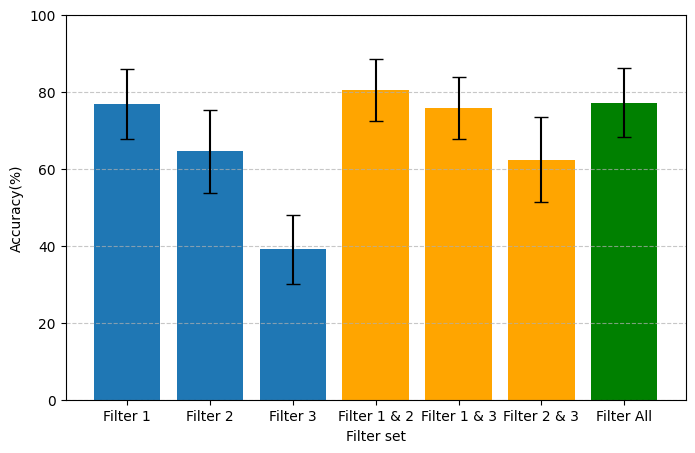

In [16]:
# Example data
models = ['Filter 1', 'Filter 2', 'Filter 3', 'Filter 1 & 2', 'Filter 1 & 3', 'Filter 2 & 3', 'Filter All']
accuracies = [np.mean(filter_1)*100, 
              np.mean(filter_2)*100, 
              np.mean(filter_3)*100, 
              np.mean(filter_1_and_2)*100, 
              np.mean(filter_1_and_3)*100, 
              np.mean(filter_2_and_3)*100,
              np.mean(filter_all)*100]

std_devs = [np.std(filter_1)/2*100,
            np.std(filter_2)/2*100,
            np.std(filter_3)/2*100,
            np.std(filter_1_and_2)/2*100,
            np.std(filter_1_and_3)/2*100,
            np.std(filter_2_and_3)/2*100,
            np.std(filter_all)/2*100]

# Create the plot
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, yerr=std_devs, color=['#1f77b4','#1f77b4','#1f77b4','orange','orange','orange','green'], capsize=5)

# Labels and title
plt.xlabel("Filter set")
plt.ylabel("Accuracy(%)")
# plt.title("Model Accuracies Comparison")
plt.ylim(0, 100)  # Set Y-axis limit from 0 to 100
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the graph
plt.show()

# Channel selection

In [18]:
channel_3 = extract_accuracies_from_file("results/eeg_results_3channels_8_90.json")
channel_6 = extract_accuracies_from_file("results/eeg_results_6channels_8_90.json")
channel_9 = extract_accuracies_from_file("results/eeg_results_9chans_8_90_250.json")
channel_64 = extract_accuracies_from_file("results/eeg_results_64channels_8_90.json")

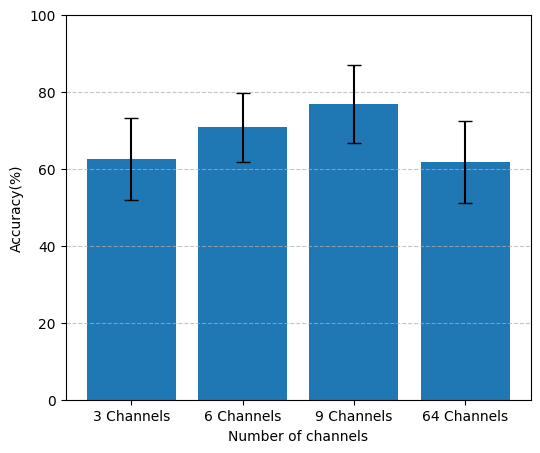

In [21]:
channels = ['3 Channels', '6 Channels', '9 Channels', '64 Channels']#, '9 Channels', '64 Channels']
data = [np.mean(channel_3)*100, np.mean(channel_6)*100, np.mean(channel_9)*100, np.mean(channel_64)*100]
stds = [np.std(channel_3)/2*100, np.std(channel_6)/2*100, np.std(channel_9)/2*100, np.std(channel_64)/2*100]

# Create the plot
plt.figure(figsize=(6, 5))
plt.bar(channels, data,yerr=stds, capsize=5)

# Labels and title
plt.xlabel("Number of channels")
plt.ylabel("Accuracy(%)")
# plt.title("Accuracies / channels comparison")
plt.ylim(0, 100)  # Set Y-axis limit from 0 to 100
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the graph
plt.show()

In [26]:
# 假设两组数据
group1 = channel_3
group2 = channel_64

# 进行独立样本t检验
t_stat, p_value = stats.ttest_ind(group1, group2)

print(f"t统计量: {t_stat}, p值: {p_value}")

if p_value < 0.05:
    print("两组数据存在显著差异")
else:
    print("两组数据无显著差异")

t统计量: 0.1653076709248548, p值: 0.8691922884694029
两组数据无显著差异
